# Ordinary Kriging — k-fold CV evaluation

Loads per-fold predictions produced by `kriging_train.ipynb` from S3, computes per-fold metrics (CRPS / MAE / RMSE) for every (transform × variogram model) combo, picks the winner by mean CRPS, and saves `winner.json` for `kriging_test.ipynb`.

Also refits the variogram per fold to check that parameters drift only a few percent vs the global fit (sanity check on the pooled climatological variogram).

## 0. Imports + paths

In [1]:
import sys, os, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import properscoring as ps

warnings.filterwarnings('ignore')

# Project-root resolver
_NB = Path.cwd()
while _NB != _NB.parent and not (_NB / 'pyproject.toml').exists():
    _NB = _NB.parent
if str(_NB / 'src') not in sys.path:
    sys.path.insert(0, str(_NB / 'src'))
os.chdir(_NB)

# ---- Local cache (mirror of S3) ----
OUT_DIR    = Path('outputs/kriging')
KFOLD_DIR  = OUT_DIR / 'kfold'
for d in (OUT_DIR, KFOLD_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- S3 ----
S3_BUCKET = 'thesis-data-ismaktam'
S3_ROOT   = 'kriging'
FOLD_S3   = 'lgbm/fold_assignment.parquet'
FORCE_RECOMPUTE = False

K_FOLDS    = 5
TRANSFORMS = ['none', 'log', 'normal_score']
VGM_MODELS = ['spherical', 'exponential', 'gaussian']

print(f'Project root: {_NB}')
print(f'S3:           s3://{S3_BUCKET}/{S3_ROOT}/')

Project root: /root/precip_interpolation_thesis
S3:           s3://thesis-data-ismaktam/kriging/


## 1. S3 helpers

In [2]:
s3 = boto3.client('s3')

def s3_exists(s3_key: str) -> bool:
    try:
        s3.head_object(Bucket=S3_BUCKET, Key=s3_key)
        return True
    except Exception:
        return False

def s3_upload(local_path: Path, s3_key: str) -> None:
    try:
        s3.upload_file(str(local_path), S3_BUCKET, s3_key)
        print(f'  ↑ s3://{S3_BUCKET}/{s3_key}')
    except Exception as e:
        print(f'  S3 upload failed: {e.__class__.__name__}: {e}')

def s3_download(s3_key: str, local_path: Path) -> bool:
    try:
        local_path.parent.mkdir(parents=True, exist_ok=True)
        s3.download_file(S3_BUCKET, s3_key, str(local_path))
        print(f'  ↓ s3://{S3_BUCKET}/{s3_key}')
        return True
    except Exception:
        return False

def fetch(s3_key: str, local_path: Path) -> bool:
    """local cache → S3 → False."""
    if local_path.exists() and not FORCE_RECOMPUTE:
        return True
    if FORCE_RECOMPUTE:
        return False
    return s3_download(s3_key, local_path)

## 2. Load per-fold predictions from S3 and aggregate CV metrics

In [3]:
fold_dfs = []
for k in range(K_FOLDS):
    local_p = KFOLD_DIR / f'fold{k}_predictions.parquet'
    s3_key  = f'{S3_ROOT}/kfold/fold{k}_predictions.parquet'
    if not fetch(s3_key, local_p):
        print(f'[fold {k}] missing in S3 ({s3_key}) — run kriging_train.ipynb first')
        continue
    df = pd.read_parquet(local_p)
    if 'fold' not in df.columns:
        df['fold'] = k
    fold_dfs.append(df)
df_all = pd.concat(fold_dfs, ignore_index=True)
print(f'Total records:    {len(df_all):,}')
print(f'Unique stations:  {df_all["station_id"].nunique()}')
print(f'Date range:       {df_all["date"].min()} → {df_all["date"].max()}')
print(f'Combos:           {df_all.groupby(["transform","variogram_model"]).ngroups}')

Total records:    407,138,940
Unique stations:  1966
Date range:       1961-01-01 → 2023-12-31
Combos:           9


In [4]:
def _metrics(grp: pd.DataFrame) -> dict:
    obs = grp['observed_mm'].values
    pred = grp['predicted_mm'].values
    sd = np.sqrt(np.maximum(grp['predicted_var_mm2'].values, 1e-8))
    return {
        'crps': float(np.mean(ps.crps_gaussian(obs, mu=pred, sig=sd))),
        'mae':  float(np.mean(np.abs(obs - pred))),
        'rmse': float(np.sqrt(np.mean((obs - pred) ** 2))),
        'n':    int(len(grp)),
    }

rows = []
for (k, t, vm), grp in df_all.groupby(['fold', 'transform', 'variogram_model']):
    rows.append({'fold': k, 'transform': t, 'variogram_model': vm, **_metrics(grp)})
metrics_df = pd.DataFrame(rows)

summary = (
    metrics_df.groupby(['transform', 'variogram_model'])
    [['crps', 'mae', 'rmse']].agg(['mean', 'std']).round(4)
)
summary.columns = ['_'.join(c) for c in summary.columns]
print('\n=== MEAN ± STD ACROSS FOLDS ===')
print(summary.sort_values('crps_mean').to_string())

winner = summary['crps_mean'].idxmin()
print(f'\nWinner (lowest mean CRPS): transform={winner[0]!r}  variogram={winner[1]!r}')


=== MEAN ± STD ACROSS FOLDS ===
                              crps_mean  crps_std  mae_mean  mae_std  rmse_mean  rmse_std
transform    variogram_model                                                             
none         exponential         0.4079    0.0069    0.5131   0.0089     1.3745    0.0190
normal_score exponential         0.4336    0.0061    0.5259   0.0084     1.4446    0.0207
log          exponential         0.4418    0.0060    0.5297   0.0085     1.4562    0.0200
none         spherical           0.4663    0.0067    0.5886   0.0088     1.4708    0.0203
normal_score spherical           0.4702    0.0062    0.5717   0.0085     1.5346    0.0214
log          spherical           0.4849    0.0062    0.5804   0.0087     1.5576    0.0210
normal_score gaussian            0.5344    0.0063    0.6836   0.0081     1.8084    0.0211
none         gaussian            0.5364    0.0068    0.7003   0.0087     1.7162    0.0219
log          gaussian            0.5468    0.0065    0.6872   0.008

## 2b. Metrics on predicted-wet records only (`predicted_mm >= 0.4 mm`)

Subset of records where the model predicted rain (`predicted_mm >= 0.4`). Same metrics (CRPS / MAE / RMSE) averaged across folds.

In [5]:
PRED_WET = 0.4  # mm

rows_pw = []
for (k, t, vm), grp in df_all.groupby(['fold', 'transform', 'variogram_model']):
    grp_clean = grp.dropna(subset=['predicted_mm', 'predicted_var_mm2'])
    pw = grp_clean[grp_clean['predicted_mm'] >= PRED_WET]
    if len(pw) == 0:
        continue
    rows_pw.append({'fold': k, 'transform': t, 'variogram_model': vm,
                    **_metrics(pw),
                    'pct_of_fold': 100.0 * len(pw) / max(len(grp_clean), 1)})
metrics_pw = pd.DataFrame(rows_pw)

summary_pw = (
    metrics_pw.groupby(['transform', 'variogram_model'])
    [['crps', 'mae', 'rmse', 'pct_of_fold']].agg(['mean', 'std']).round(4)
)
summary_pw.columns = ['_'.join(c) for c in summary_pw.columns]
print('\n=== PREDICTED-WET ONLY (predicted_mm >= 0.4 mm) — MEAN \u00b1 STD ACROSS FOLDS ===')
print(summary_pw.sort_values('crps_mean').to_string())

winner_pw = summary_pw['crps_mean'].idxmin()
print(f'\nWinner predicted-wet (lowest mean CRPS): transform={winner_pw[0]!r}  variogram={winner_pw[1]!r}')

summary_pw.to_csv(OUT_DIR / 'metrics_pred_wet.csv')
print(f'saved \u2192 {OUT_DIR}/metrics_pred_wet.csv')


=== PREDICTED-WET ONLY (predicted_mm >= 0.4 mm) — MEAN ± STD ACROSS FOLDS ===
                              crps_mean  crps_std  mae_mean  mae_std  rmse_mean  rmse_std  pct_of_fold_mean  pct_of_fold_std
transform    variogram_model                                                                                                
none         exponential         0.9055    0.0126    1.1623   0.0171     2.1013    0.0267           40.9496           0.1512
normal_score exponential         0.9683    0.0109    1.1937   0.0170     2.2131    0.0298           40.9495           0.1511
log          exponential         0.9883    0.0107    1.2028   0.0171     2.2317    0.0288           40.9497           0.1511
none         spherical           1.0480    0.0120    1.3468   0.0171     2.2548    0.0290           40.9497           0.1512
normal_score spherical           1.0575    0.0110    1.3055   0.0172     2.3565    0.0311           40.9496           0.1511
log          spherical           1.0934    0.0

## 3. Sanity check: per-fold variogram stability

Refits the variogram on each fold's train stations only and compares to the global fit. If parameters drift only a few percent, the pooled-variogram choice (Haylock 2008) is safe under k-fold CV.

*(slow — runs `GlobalVariogramFitter.fit` 5 extra times)*

In [6]:
RUN_SANITY_CHECK = True   # set False to skip

VGM_LOCAL = OUT_DIR / 'global_variogram.pkl'
VGM_S3    = f'{S3_ROOT}/global_variogram.pkl'
if not fetch(VGM_S3, VGM_LOCAL):
    raise FileNotFoundError(f'global_variogram.pkl not in S3 — run kriging_train.ipynb first')
with open(VGM_LOCAL, 'rb') as f:
    payload = pickle.load(f)
# Pickle from kriging_train is a wrapped payload {'variograms': {(t,vm): info}, 'empirical': ..., 'lag_centers_km': ...}
# Unwrap to the inner {(t, vm) -> info} dict expected by the iteration below.
global_vgm = payload['variograms'] if isinstance(payload, dict) and 'variograms' in payload else payload
assert all(isinstance(k, tuple) and len(k) == 2 for k in global_vgm), \
    f'global_vgm has unexpected keys: {list(global_vgm)[:5]} — expected tuples of (transform, variogram_model)'

if RUN_SANITY_CHECK:
    from thesis.config import Config
    from thesis.data.registry import DataRegistry
    from thesis.scripts._common import load_and_fit_pipeline
    from thesis.models.kriging.variogram_fitter import GlobalVariogramFitter

    cfg = Config()
    registry = DataRegistry.from_config(cfg)
    _, all_proc, fwd, _, proc_by_date, _ = load_and_fit_pipeline(
        cfg, registry, cfg.date_start, cfg.date_end,
    )

    # Load fold assignment from S3 (canonical source)
    FOLD_LOCAL = OUT_DIR / 'fold_assignment.parquet'
    if not fetch(FOLD_S3, FOLD_LOCAL):
        raise FileNotFoundError(f'fold_assignment.parquet not in S3 at s3://{S3_BUCKET}/{FOLD_S3}')
    fold_df = pd.read_parquet(FOLD_LOCAL)
    fold_map = dict(zip(fold_df['station_id'], fold_df['fold']))
    all_proc['fold'] = all_proc['station_id'].map(fold_map).astype('Int64')

    fold_vgms = {}
    for k in range(K_FOLDS):
        train_proc = all_proc[all_proc['fold'] != k]
        proc_by_date_k = {str(d): grp for d, grp in train_proc.groupby('date')}
        pool = [proc_by_date_k[d] for d in sorted(proc_by_date_k)
                if (proc_by_date_k[d]['rain_indicator'] == 1).sum() >= 5]
        fitter_k = GlobalVariogramFitter(
            transforms=TRANSFORMS, variogram_models=VGM_MODELS,
            n_lags=cfg.kriging.variogram_nlags, max_lag_km=cfg.kriging.search_radius_km,
            min_pairs=30, checkpoint_path=None, n_jobs=-1,
        )
        result_k = fitter_k.fit(pool, fwd_fn=fwd)
        # Same unwrap (fitter._result is the wrapped payload).
        fold_vgms[k] = result_k['variograms'] if isinstance(result_k, dict) and 'variograms' in result_k else result_k
        print(f'[fold {k}] refit complete')

    rows = []
    for (t, vm), info_global in global_vgm.items():
        if t == 'indicator' or info_global is None:
            continue
        gp = info_global['params_dict']
        for k, vgm_k in fold_vgms.items():
            info_k = vgm_k.get((t, vm))
            if info_k is None:
                continue
            kp = info_k['params_dict']
            rows.append({
                'transform': t, 'variogram_model': vm, 'fold': k,
                'nugget_pct_diff': 100 * (kp['nugget'] - gp['nugget']) / max(abs(gp['nugget']), 1e-8),
                'psill_pct_diff':  100 * (kp['psill'] - gp['psill']) / max(abs(gp['psill']), 1e-8),
                'range_pct_diff':  100 * (kp['range'] - gp['range']) / max(abs(gp['range']), 1e-8),
            })
    sens = pd.DataFrame(rows)
    print('\n=== PER-FOLD VARIOGRAM PARAMETER DRIFT (vs global fit, %) ===')
    print(sens.groupby(['transform', 'variogram_model'])[
        ['nugget_pct_diff', 'psill_pct_diff', 'range_pct_diff']
    ].agg(['mean', 'max']).round(2).to_string())
    print('\n→ If max drift < 5% across all (transform × model × fold), Haylock pooling is empirically robust.')
    sens_local = OUT_DIR / 'variogram_fold_sensitivity.csv'
    sens.to_csv(sens_local, index=False)
    s3_upload(sens_local, f'{S3_ROOT}/variogram_fold_sensitivity.csv')

[10:21:30] Loading raw data: 1961-01-01 … 2023-12-31
[10:21:41]   45,237,660 rows, 1966 stations
[10:21:41] Fitting base pipeline: Projection → Indicator → Detrend
[10:21:59]   Fitting NormalScoreTransform…
[10:22:01]   NormalScoreTransform CDF: 17,409,376 wet quotas


[1/3] 'none' — fwd transform:   0%|          | 0/19950 [00:00<?, ?day/s]

  Accumulating semi-variances: 19950 days, n_jobs=-1, device=CPU
Transform 'none': 7,551,015,262 pairs, sill_est=0.0080
  Bins with pairs: 38/38
  spherical    -> nugget=0.0018  psill=0.0060  range=216 km  chi2r=5.429
  exponential  -> nugget=0.0003  psill=0.0078  range=79 km  chi2r=4.965
  gaussian     -> nugget=0.0027  psill=0.0051  range=105 km  chi2r=8.913


[2/3] 'log' — fwd transform:   0%|          | 0/19950 [00:00<?, ?day/s]

  Accumulating semi-variances: 19950 days, n_jobs=-1, device=CPU
Transform 'log': 7,551,015,262 pairs, sill_est=0.7645
  Bins with pairs: 38/38
  spherical    -> nugget=0.2512  psill=0.4660  range=326 km  chi2r=78498.197
  exponential  -> nugget=0.1718  psill=0.6117  range=148 km  chi2r=12612.930
  gaussian     -> nugget=0.3114  psill=0.3965  range=152 km  chi2r=140387.339


...

  Accumulating semi-variances: 20117 days, n_jobs=-1, device=CPU
Transform 'none': 7,597,836,029 pairs, sill_est=0.0079
  Bins with pairs: 38/38
  spherical    -> nugget=0.0018  psill=0.0059  range=217 km  chi2r=5.504
  exponential  -> nugget=0.0003  psill=0.0077  range=79 km  chi2r=4.461
  gaussian     -> nugget=0.0026  psill=0.0051  range=105 km  chi2r=8.627


[2/3] 'log' — fwd transform:   0%|          | 0/20117 [00:00<?, ?day/s]

  Accumulating semi-variances: 20117 days, n_jobs=-1, device=CPU
Transform 'log': 7,597,836,029 pairs, sill_est=0.7667
  Bins with pairs: 38/38
  spherical    -> nugget=0.2506  psill=0.4689  range=329 km  chi2r=79109.175
  exponential  -> nugget=0.1714  psill=0.6157  range=150 km  chi2r=12477.967
  gaussian     -> nugget=0.3109  psill=0.3991  range=153 km  chi2r=142123.715


[3/3] 'normal_score' — fwd transform:   0%|          | 0/20117 [00:00<?, ?day/s]

  Accumulating semi-variances: 20117 days, n_jobs=-1, device=CPU
Transform 'normal_score': 7,597,836,029 pairs, sill_est=0.8061
  Bins with pairs: 38/38
  spherical    -> nugget=0.2676  psill=0.4900  range=346 km  chi2r=82700.722
  exponential  -> nugget=0.1909  psill=0.6462  range=164 km  chi2r=15437.089
  gaussian     -> nugget=0.3297  psill=0.4153  range=160 km  chi2r=155688.214

Global variograms fitted.
[fold 4] refit complete

=== PER-FOLD VARIOGRAM PARAMETER DRIFT (vs global fit, %) ===
                             nugget_pct_diff       psill_pct_diff       range_pct_diff      
                                        mean   max           mean   max           mean   max
transform    variogram_model                                                                
log          exponential               -0.05  0.56           0.01  0.54          -0.02  0.63
             gaussian                  -0.02  0.28           0.01  0.53          -0.01  0.37
             spherical              

## 4. Per-fold metric bar charts

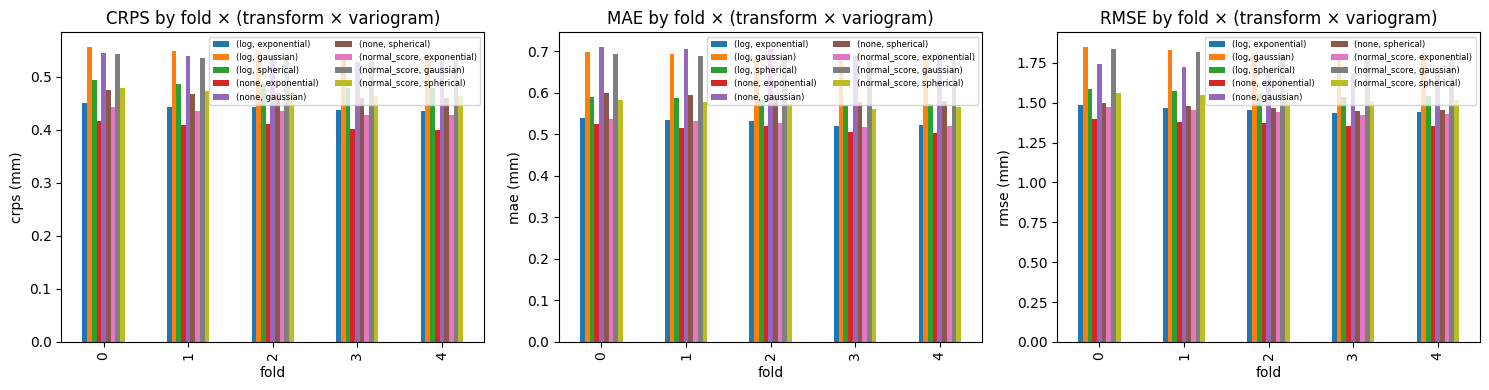

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['crps', 'mae']):
    pivot = metrics_df.pivot_table(index='fold', columns=['transform', 'variogram_model'], values=metric)
    pivot.plot.bar(ax=ax)
    ax.set_title(f'{metric.upper()} by fold × (transform × variogram)')
    ax.set_xlabel('fold')
    ax.set_ylabel(f'{metric} (mm)')
    ax.legend(loc='upper right', fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

## 5. Predicted-vs-observed scatter (winning combo)

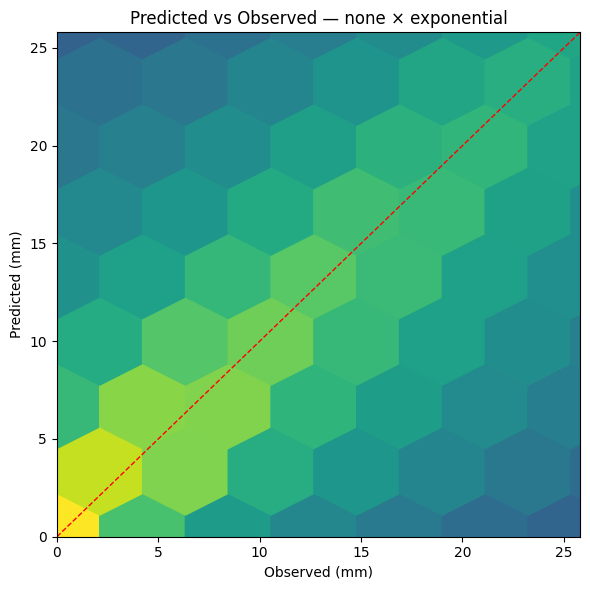

In [8]:
win_df = df_all[(df_all['transform'] == winner[0]) & (df_all['variogram_model'] == winner[1])]
obs = win_df['observed_mm'].values
pred = win_df['predicted_mm'].values

fig, ax = plt.subplots(figsize=(6, 6))
ax.hexbin(obs, pred, gridsize=80, cmap='viridis', mincnt=1, bins='log')
lim = max(np.percentile(obs, 99.5), np.percentile(pred, 99.5))
ax.plot([0, lim], [0, lim], 'r--', lw=1)
ax.set_xlabel('Observed (mm)')
ax.set_ylabel('Predicted (mm)')
ax.set_title(f'Predicted vs Observed — {winner[0]} × {winner[1]}')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

## 6. Per-station spatial error map (winning combo)

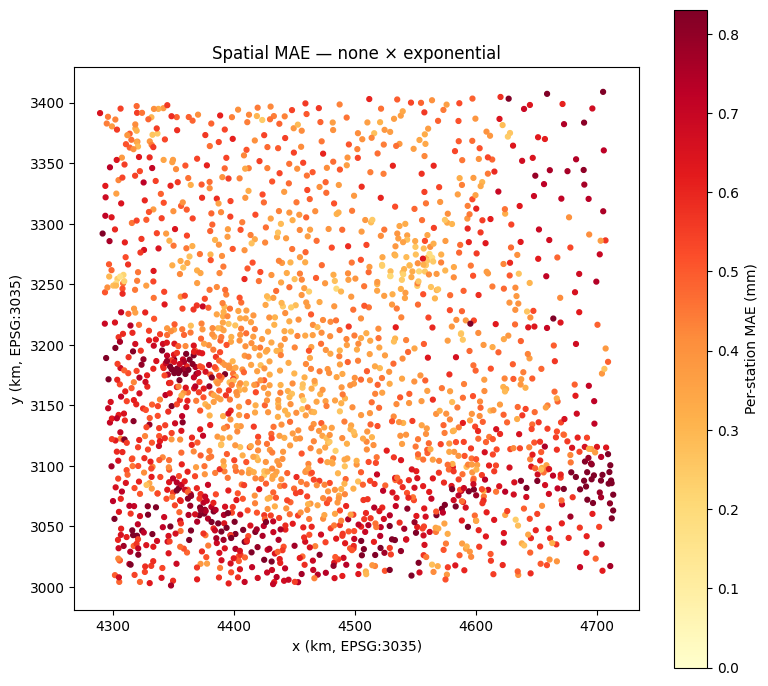

In [12]:
from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import ProjectionTransform

cfg = Config()
registry = DataRegistry.from_config(cfg)
all_raw  = registry.stations.load(cfg.date_start, cfg.date_end)
proj = ProjectionTransform(target_crs=cfg.study_area.target_crs)
all_proc = proj.fit(all_raw).apply(all_raw)
station_meta = (
      all_proc.drop_duplicates('station_id')
              [['station_id', 'x_proj', 'y_proj']]
  )

abs_err = (win_df['observed_mm'] - win_df['predicted_mm']).abs()
station_err = (
    win_df.assign(abs_err=abs_err)
    .groupby('station_id')['abs_err'].mean()
    .reset_index().rename(columns={'abs_err': 'mae'})
    .merge(station_meta, on='station_id', how='left')
)

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(
    station_err['x_proj'] / 1000,
    station_err['y_proj'] / 1000,
    c=station_err['mae'], cmap='YlOrRd', s=12,
    vmin=0, vmax=np.nanpercentile(station_err['mae'], 95),
)
plt.colorbar(sc, ax=ax, label='Per-station MAE (mm)')
ax.set_xlabel('x (km, EPSG:3035)')
ax.set_ylabel('y (km, EPSG:3035)')
ax.set_title(f'Spatial MAE — {winner[0]} × {winner[1]}')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 7. Save winner config to S3 (consumed by `kriging_test.ipynb`)

In [13]:
winner_payload = {
    'transform':       winner[0],
    'variogram_model': winner[1],
    'mean_crps':       float(summary.loc[winner, 'crps_mean']),
    'mean_mae':        float(summary.loc[winner, 'mae_mean']),
    'mean_rmse':       float(summary.loc[winner, 'rmse_mean']),
}
winner_local = OUT_DIR / 'winner.json'
with open(winner_local, 'w') as f:
    json.dump(winner_payload, f, indent=2)
s3_upload(winner_local, f'{S3_ROOT}/winner.json')
print(json.dumps(winner_payload, indent=2))

  ↑ s3://thesis-data-ismaktam/kriging/winner.json
{
  "transform": "none",
  "variogram_model": "exponential",
  "mean_crps": 0.4079,
  "mean_mae": 0.5131,
  "mean_rmse": 1.3745
}


## 8. S3 manifest

In [14]:
print('=== S3 ARTEFACTS (eval outputs) ===')
for key in ['winner.json', 'variogram_fold_sensitivity.csv']:
    print(f'  s3://{S3_BUCKET}/{S3_ROOT}/{key}  '
          f'{"✓" if s3_exists(f"{S3_ROOT}/{key}") else "✗"}')

=== S3 ARTEFACTS (eval outputs) ===
  s3://thesis-data-ismaktam/kriging/winner.json  ✓
  s3://thesis-data-ismaktam/kriging/variogram_fold_sensitivity.csv  ✓
